* question_set에 존재하는 10개의 학교 학생을 대상으로,
* 기존 분석 재 실행

## 0. 라이브러리 호출 및 환경 세팅

### 0-1. 라이브러리 호출

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.cloud import bigquery

### 0-2. 시각화 공통 환경 세팅

In [3]:
sns.set_theme(style="darkgrid")

plt.rc('font', family='AppleGothic')
# 마이너스 폰트 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

### 0-3. 함수 정의

In [11]:
def plot_monthly_signups(data, title):
    data = data.sort_values('signup_month').copy()
    data['monthly_change'] = data['unique_users'].diff()

    fig, ax = plt.subplots(figsize=(16, 6))

    # 라인그래프 생성
    sns.lineplot(
        data=data,
        x='signup_month',
        y='unique_users',
        marker='o',
        linewidth=2.5,
        color='#3182bd',
        ax=ax,
    )

    # 표시된 월별 가입자 수의 중앙값
    median_users = data['unique_users'].median()
    ax.axhline(
        y=median_users,
        color='darkorange',
        linestyle='--',
        linewidth=1.5,
        label=f'중앙값: {median_users:,.0f}명',
    )
    ax.legend(loc='upper right')

    # 각 데이터 포인트에 숫자 레이블 표시
    for row in data.itertuples(index=False):
        x, y, change = (
            row.signup_month,
            row.unique_users,
            row.monthly_change,
        )
        # 중앙값 이상인 월의 가입자 수 강조
        is_above_median = y >= median_users
        ax.annotate(
            f'{int(y):,}명',
            (x, y),
            xytext=(0, 23),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color='black',
            fontweight='bold' if is_above_median else 'normal',
            bbox=(
                dict(
                    boxstyle='round,pad=0.25',
                    facecolor='#FFF3CD',
                    edgecolor='darkorange',
                    linewidth=0.8,
                )
                if is_above_median else None
            ),
        )

        # 전월 대비 증감량
        if pd.isna(change):
            label, color = '비교 없음', 'gray'
        elif change > 0:
            label, color = f'+{int(change):,}명', 'red'
        elif change < 0:
            label, color = f'{int(change):,}명', 'blue'
        else:
            label, color = '0명', 'gray'

        ax.annotate(
            label,
            (x, y),
            xytext=(0, 7),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color=color,
        )

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('가입 월', fontsize=11)
    ax.set_ylabel('가입 유저 수(명)', fontsize=11)

    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim(0, data['unique_users'].max() * 1.25)

    fig.tight_layout()
    plt.show()

In [19]:
def plot_area_signups(data, label_col, title):
    fig, ax = plt.subplots(
        figsize=(12, max(5, len(data) * 0.4))
    )

    bars = ax.barh(
        data[label_col],
        data['가입자 수'],
        color='#3182bd',
    )

    ax.bar_label(
        bars,
        labels=[
            f'{count:,.0f}명 ({share:.2f}%)'
            for count, share in zip(data['가입자 수'], data['비중(%)'])
        ],
        padding=5,
        fontsize=9,
    )

    ax.invert_yaxis()
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('가입자 수(명)')
    ax.set_ylabel('')
    ax.set_xlim(0, data['가입자 수'].max() * 1.35)

    fig.tight_layout()
    plt.show()


In [24]:
def summarize_group_burst(group, window_hours=24):
    times = group['signup_date'].sort_values().reset_index(drop=True)
    window = pd.Timedelta(hours=window_hours)
    right = 0
    best_left = 0
    best_count = 0

    for left in range(len(times)):
        while right < len(times) and times.iloc[right] < times.iloc[left] + window:
            right += 1
        count = right - left
        if count > best_count:
            best_left = left
            best_count = count

    start = times.iloc[best_left]
    return {
        '가입자 수': len(times),
        '최대 구간 가입자 수': best_count,
        '가입 집중도(%)': best_count / len(times) * 100,
        '집중 구간 시작': start,
        '집중 구간 종료(미포함)': start + window,
        '그룹 최초 가입': times.iloc[0],
        '그룹 최종 가입': times.iloc[-1],
    }

In [25]:
def analyze_signup_bursts(data, entity_col, min_users, window_hours):
    # 1. 필요한 컬럼 선택 및 결측·중복 정리
    signups = (
        data[['user_id', entity_col, 'signup_date']]
        .dropna(subset=['user_id', entity_col, 'signup_date'])
        .sort_values('signup_date')
        .drop_duplicates([entity_col, 'user_id'], keep='first')
        .copy()
    )

    # 시간 변환 없이 기존 datetime 사용
    if not pd.api.types.is_datetime64_any_dtype(signups['signup_date'].dtype):
        raise TypeError('signup_date가 datetime 형식인지 확인해 주세요.')

    # 2. 최소 인원 이상인 집단만 선택
    sizes = signups.groupby(entity_col)['user_id'].nunique()
    eligible_ids = sizes[sizes >= min_users].index

    eligible_signups = signups[
        signups[entity_col].isin(eligible_ids)
    ]

    # 3. 기존 함수를 각 집단에 적용
    records = []

    for entity_id, members in eligible_signups.groupby(entity_col):
        records.append({
            entity_col: entity_id,
            **summarize_group_burst(
                members,
                window_hours=window_hours,
            ),
        })

    # 4. 결과표 생성
    columns = [
        entity_col,
        '가입자 수',
        '최대 구간 가입자 수',
        '가입 집중도(%)',
        '집중 구간 시작',
        '집중 구간 종료(미포함)',
        '그룹 최초 가입',
        '그룹 최종 가입',
    ]

    summary = (
        pd.DataFrame(records, columns=columns)
        .rename(columns={
            '그룹 최초 가입': '최초 가입',
            '그룹 최종 가입': '최종 가입',
        })
        .sort_values(
            ['가입 집중도(%)', '최대 구간 가입자 수'],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

    coverage = pd.DataFrame({
        '구분': ['전체 유효 집단', '분석 대상 집단', '최소 인원 미달 집단'],
        '집단 수': [
            len(sizes),
            len(eligible_ids),
            len(sizes) - len(eligible_ids),
        ],
    })

    return summary, coverage

In [26]:
def summarize_burst_distribution(
    data,
    entity_label='학교',
    window_hours=72,
):
    labels = [
        f'{start}~{start + 10}% 미만'
        for start in range(0, 90, 10)
    ] + ['90~100%']

    count_col = f'{entity_label} 수'
    share_col = f'{entity_label} 비중(%)'

    distribution = (
        pd.cut(
            data['가입 집중도(%)'],
            bins=list(range(0, 100, 10)) + [float('inf')],
            labels=labels,
            right=False,
        )
        .value_counts(sort=False)
        .rename_axis(f'{window_hours}시간 가입 집중도 구간')
        .reset_index(name=count_col)
    )

    distribution[share_col] = (
        (distribution[count_col] / len(data) * 100).round(2)
        if len(data) else float('nan')
    )

    return distribution

### 0-4. 데이터 호출

In [5]:
PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [6]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.stg_acquisition_user`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

   user_id                      signup_date  group_id  grade  school_id  \
0   854579 2023-04-29 14:58:10.258013+00:00      5384      1       5635   
1   860264 2023-04-30 13:57:44.499021+00:00      6687      1       5257   
2   860491 2023-04-30 14:12:42.390512+00:00      2842      1       2588   
3   877440 2023-05-03 14:51:51.083512+00:00      2658      1       2599   
4   949655 2023-05-07 07:22:57.503677+00:00     18574      1       4496   

       address school_type  
0      경기도 가평군           H  
1  경기도 성남시 분당구           H  
2    서울특별시 강남구           H  
3    서울특별시 강남구           H  
4      경기도 화성시           H  


In [8]:
df = df[df['school_id'].isin([271, 352, 369, 1478, 1719, 4426, 4516, 5372, 5491, 5520])]

In [9]:
# 데이터 규모
print(f'분석 데이터 규모 {df.shape}')
print(df['user_id'].nunique())

분석 데이터 규모 (5090, 7)
5090


## 1. 월별 가입자 추이 분석

- **분석 대상:** 5090명

- 전체 사용자의 **가입 일시를 기준으로 월별 신규 가입자 수의 추이와 변화 패턴**을 확인합니다.

In [10]:
# datetime 변환 후 YYYY-MM 포맷으로 추출
df['signup_month'] = pd.to_datetime(df['signup_date']).dt.strftime('%Y-%m')

# 연월별 유니크 가입자 수 집계
monthly_summary = df.groupby(by='signup_month')['user_id'].nunique().reset_index(name='unique_users')
# 실제 전월과 비교하도록 누락된 월도 포함하고 시간순으로 정렬
monthly_summary = (
    monthly_summary.set_index('signup_month')
    .reindex(
        pd.period_range(
            monthly_summary['signup_month'].min(),
            monthly_summary['signup_month'].max(),
            freq='M',
        ).astype(str),
        fill_value=0,
    )
    .rename_axis('signup_month')
    .reset_index()
)

print(monthly_summary.head())

  signup_month  unique_users
0      2023-04           403
1      2023-05          4632
2      2023-06            35
3      2023-07             4
4      2023-08             2


findfont: Failed to find font weight bold, now using 400.


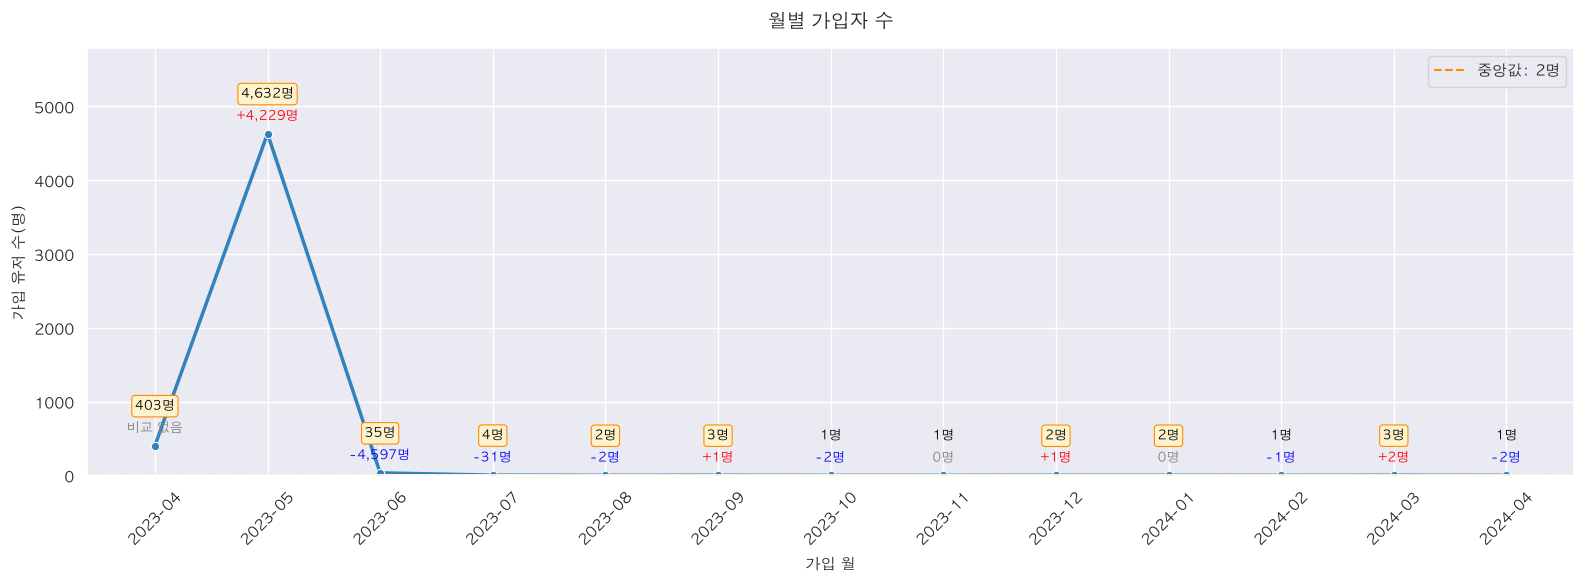

In [12]:
plot_monthly_signups(monthly_summary, '월별 가입자 수')

## 2. 가입자 구성 분석

In [13]:
school_summary = (
    df.groupby('school_type')['user_id']
      .nunique()
      .reset_index(name='unique_users')
)

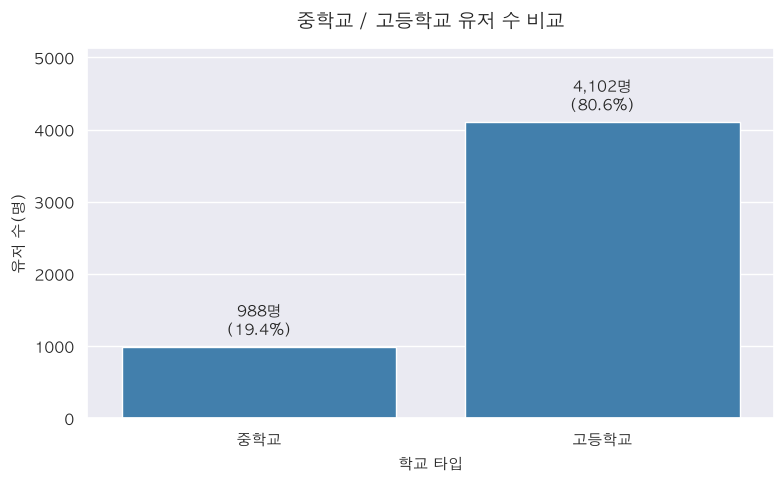

In [14]:
plt.figure(figsize=(8, 5))

# 막대그래프
ax = sns.barplot(
    data=school_summary,
    x='school_type',
    y='unique_users',
    order=['M', 'H'],
    color='#3182bd'
)

ax.set_xticks([0, 1], labels=['중학교', '고등학교'])

# 그래프에 표시된 학교급 전체 가입자 수 기준
total_users = school_summary['unique_users'].sum()

# 막대 위에 숫자 표시
for p in ax.patches:
    height = p.get_height()
    share = height / total_users * 100 if total_users else 0
    ax.annotate(
        f'{int(height):,}명\n({share:.1f}%)',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=11,
    )

plt.title('중학교 / 고등학교 유저 수 비교', fontsize=14, pad=15)
plt.xlabel('학교 타입', fontsize=11)
plt.ylabel('유저 수(명)', fontsize=11)

# 위쪽 숫자가 잘리지 않도록 여유 공간
plt.ylim(0, school_summary['unique_users'].max() * 1.25)

plt.tight_layout()
plt.show()

In [15]:
# 학교급·학년별 고유 가입자 수 집계
school_grade_summary = (
    df.groupby(['school_type', 'grade'])['user_id']
      .nunique()
      .reset_index(name='unique_users')
)

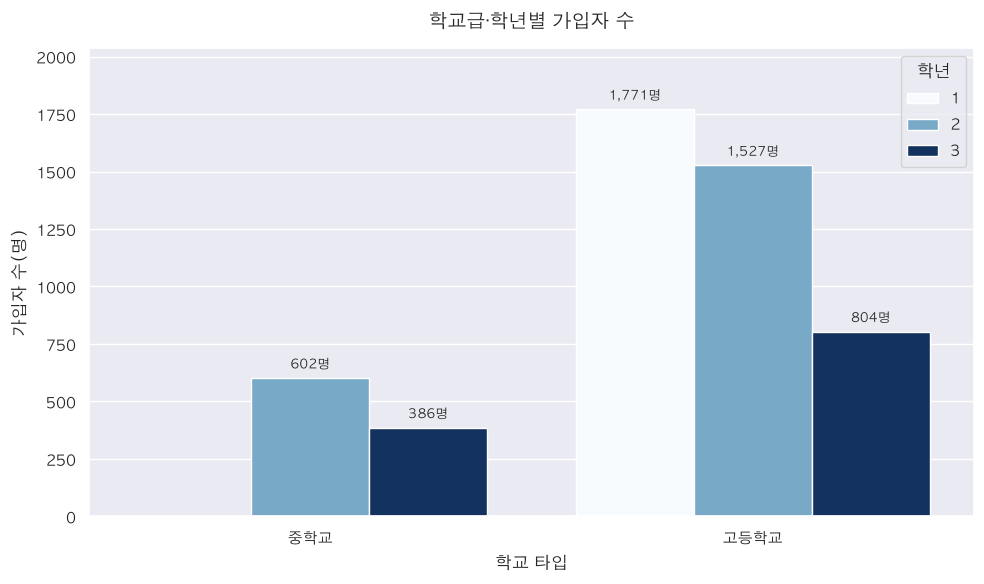

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=school_grade_summary,
    x='school_type',
    y='unique_users',
    hue='grade',
    order=['M', 'H'],
    palette='Blues',
    ax=ax,
)

ax.set_xticks([0, 1], labels=['중학교', '고등학교'])

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{value:,.0f}명' for value in container.datavalues],
        padding=4,
        fontsize=9,
    )

ax.set_title('학교급·학년별 가입자 수', fontsize=14, pad=15)
ax.set_xlabel('학교 타입')
ax.set_ylabel('가입자 수(명)')
ax.legend(title='학년')
ax.set_ylim(0, school_grade_summary['unique_users'].max() * 1.15)

fig.tight_layout()
plt.show()


## 3. 학교 위치 별 유저 수 비교

In [17]:
# 학교 소재지 기준: 주소 공백 정리 및 지역 구분
area_df = df.copy()

address = (
    area_df['address']
    .astype('string')
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .replace({'-': pd.NA, '': pd.NA})
)

parts = address.str.split(n=2, expand=True)

area_df['시도'] = parts[0].fillna('미상')
area_df['시군구'] = parts.reindex(columns=[1])[1].fillna('미기재')

# 시·도별 고유 가입자 수
region_summary = (
    area_df.groupby('시도')['user_id']
    .nunique()
    .reset_index(name='가입자 수')
    .sort_values('가입자 수', ascending=False)
)

# 시·도 + 시·군·구별 고유 가입자 수
city_summary = (
    area_df.groupby(['시도', '시군구'])['user_id']
    .nunique()
    .reset_index(name='가입자 수')
    .sort_values('가입자 수', ascending=False)
)

# 전체 고유 가입자 대비 지역별 비중
total_users = area_df['user_id'].nunique()

region_summary['비중(%)'] = (
    region_summary['가입자 수'] / total_users * 100
).round(2)

city_summary['비중(%)'] = (
    city_summary['가입자 수'] / total_users * 100
).round(2)

# display(region_summary)
# display(city_summary)


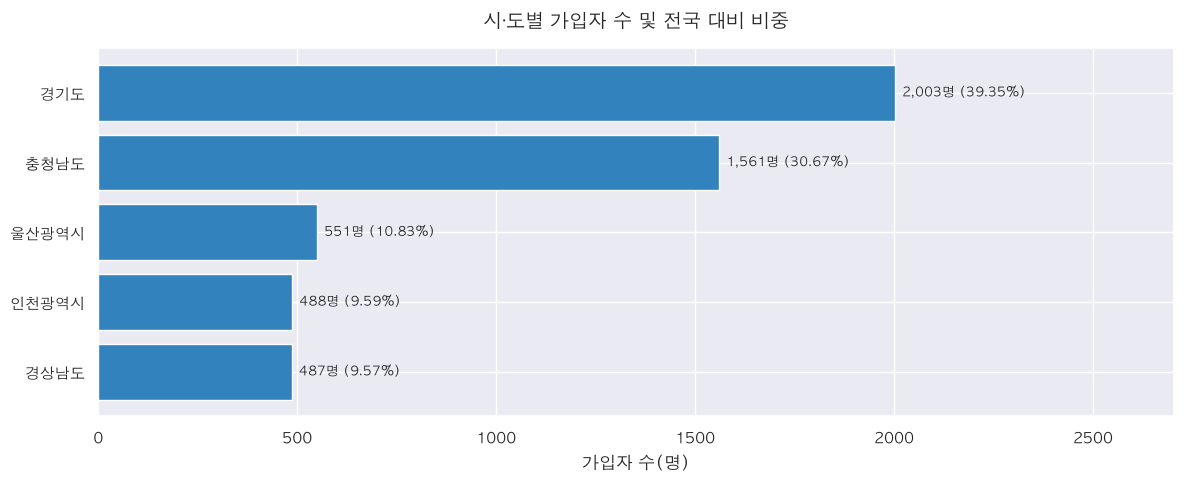

In [20]:
plot_area_signups(
    region_summary.sort_values('가입자 수', ascending=False),
    '시도',
    '시·도별 가입자 수 및 전국 대비 비중',
)

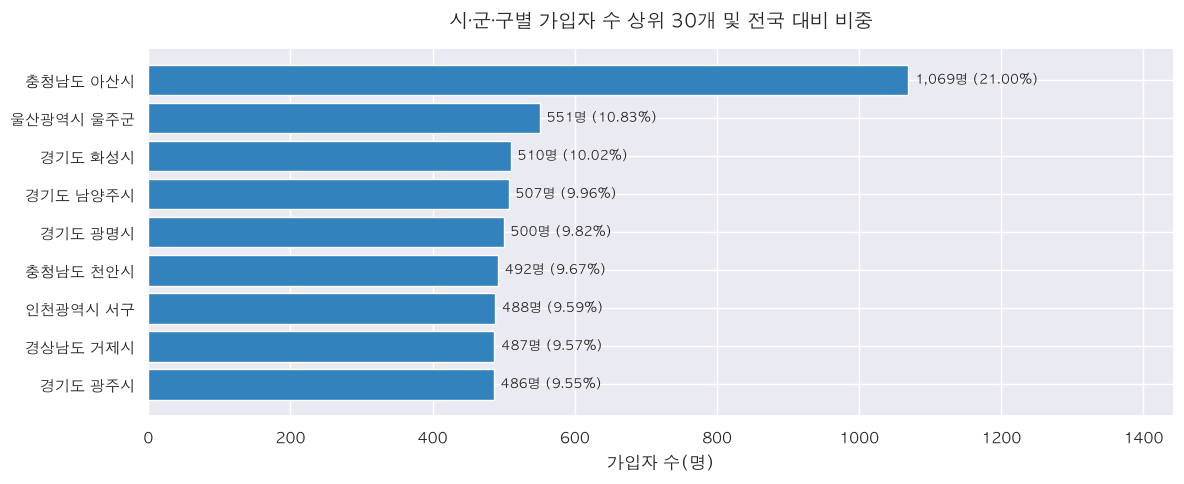

In [21]:
city_top30 = (
    city_summary.nlargest(30, '가입자 수')
    .copy()
)

city_top30['지역'] = city_top30['시도'] + ' ' + city_top30['시군구']

plot_area_signups(
    city_top30,
    '지역',
    '시·군·구별 가입자 수 상위 30개 및 전국 대비 비중',
)

In [22]:
# 전체 시·군·구별 가입자 수의 평균과 중앙값
# 시·도별 평균의 평균이 아니라, city_summary 전체 행을 기준으로 계산합니다.
overall_area_summary = pd.DataFrame([{
    '기준': '전체 시·군·구 (현재 집계 기준)',
    '시군구수': len(city_summary),
    '평균': city_summary['가입자 수'].mean(),
    '중앙값': city_summary['가입자 수'].median(),
}])

display(
    overall_area_summary.style.format(
        {'평균': '{:,.1f}', '중앙값': '{:,.1f}'}
    )
)

# 시·도 내 시·군·구별 가입자 수의 표준편차가 작은 순서
# 현재 집계에 포함된 지역 기준이며, 가입자가 없는 미관측 지역은 포함하지 않습니다.
region_dispersion = (
    city_summary.groupby('시도')['가입자 수']
    .agg(
        시군구수='size',
        평균='mean',
        중앙값='median',
        표준편차=lambda values: values.std(ddof=0),
    )
    .reset_index()
)

# 비교 대상이 하나뿐인 지역은 순위를 매기지 않습니다.
comparable = region_dispersion['시군구수'].ge(2)
region_dispersion.loc[~comparable, '표준편차'] = float('nan')
region_dispersion['순위'] = (
    region_dispersion['표준편차'].rank(method='min').astype('Int64')
)
region_dispersion = (
    region_dispersion.sort_values(['표준편차', '시도'], na_position='last')
    [['순위', '시도', '시군구수', '평균', '중앙값', '표준편차']]
    .reset_index(drop=True)
)

display(
    region_dispersion.style.format(
        {'평균': '{:,.1f}', '중앙값': '{:,.1f}', '표준편차': '{:,.1f}'},
        na_rep='비교 제외',
    )
)



,기준,시군구수,평균,중앙값
0,전체 시·군·구 (현재 집계 기준),9,565.6,500.0


,순위,시도,시군구수,평균,중앙값,표준편차
0,1,경기도,4,500.8,503.5,9.3
1,2,충청남도,2,780.5,780.5,288.5
2,비교 제외,경상남도,1,487.0,487.0,비교 제외
3,비교 제외,울산광역시,1,551.0,551.0,비교 제외
4,비교 제외,인천광역시,1,488.0,488.0,비교 제외


#### 💡 10개 학교 대상 기초 분석

- 전체 학교를 대상으로 진행한 기존 분석과 달리, 이번 분석에서는 **`question_set` 데이터가 존재하는 10개 학교만을 대상으로 가입 패턴을 확인**했습니다.

- 분석 결과, 전체 학교를 대상으로 한 기존 분석과 **일부 유사한 패턴이 나타나는 것을 확인**했습니다.

- 다만 분석 대상이 **10개 학교로 제한되어 있으며, 해당 학교들이 전체 학교를 대표한다고 보기 어렵기 때문에** 본 결과를 전체 사용자 및 학교의 일반적인 특성으로 확대하여 해석하는 데에는 한계가 있습니다.

> 따라서 본 분석은 **제한된 학교 내에서 기존 패턴이 유사하게 나타나는지 확인하기 위한 탐색적 분석**으로 활용합니다.

## 4. 집단 가입 패턴 및 확산 속도 분석

In [27]:
group_burst_summary, group_coverage = analyze_signup_bursts(
    df,
    entity_col='group_id',
    min_users=4,
    window_hours=24,
)

display(group_coverage)
display(group_burst_summary.head(5))

,구분,집단 수
0,전체 유효 집단,353
1,분석 대상 집단,325
2,최소 인원 미달 집단,28


,group_id,가입자 수,최대 구간 가입자 수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),최초 가입,최종 가입
0,43124,24,24,100.000000,2023-05-11 01:12:49.669935+00:00,2023-05-12 01:12:49.669935+00:00,2023-05-11 01:12:49.669935+00:00,2023-05-12 00:57:01.749899+00:00
1,2419,13,13,100.000000,2023-05-05 02:52:59.343747+00:00,2023-05-06 02:52:59.343747+00:00,2023-05-05 02:52:59.343747+00:00,2023-05-05 19:27:46.203783+00:00
2,46583,19,18,94.736842,2023-05-11 13:04:57.827381+00:00,2023-05-12 13:04:57.827381+00:00,2023-05-11 13:04:57.827381+00:00,2023-05-17 09:57:10.588679+00:00
3,356,33,31,93.939394,2023-04-28 02:54:59.981972+00:00,2023-04-29 02:54:59.981972+00:00,2023-04-20 00:11:00.962160+00:00,2023-04-29 00:59:25.428079+00:00
4,50945,14,13,92.857143,2023-05-13 09:20:14.727413+00:00,2023-05-14 09:20:14.727413+00:00,2023-05-12 13:47:43.735216+00:00,2023-05-14 04:40:40.183338+00:00


In [29]:
group_distribution = summarize_burst_distribution(
    group_burst_summary,
    entity_label='학급',
    window_hours=24,
)

display(group_distribution)

,24시간 가입 집중도 구간,학급 수,학급 비중(%)
0,0~10% 미만,0,0.00
1,10~20% 미만,4,1.23
2,20~30% 미만,27,8.31
3,30~40% 미만,53,16.31
4,40~50% 미만,70,21.54
5,50~60% 미만,57,17.54
6,60~70% 미만,49,15.08
7,70~80% 미만,45,13.85
8,80~90% 미만,13,4.00
9,90~100%,7,2.15


#### 💡 집단 가입 집중도 분석

- 가입 집중도는 **40~60% 구간에 가장 많은 그룹이 분포**하며, 특히 **40~50% 구간이 21.54%로 가장 높은 비중**을 차지합니다.

- 전체 그룹의 약 **74.16%가 가입 집중도 40% 이상**, 약 **52.62%가 50% 이상**으로 나타났습니다. 즉, 상당수 그룹에서 **관측된 가입자의 절반가량이 특정 24시간 내 집중적으로 가입하는 패턴**을 확인할 수 있습니다.

- 특히 가입 집중도가 **70% 이상인 그룹도 약 20%** 존재하여, 일부 그룹에서는 구성원의 상당수가 짧은 시간 내 연속적으로 가입하는 강한 집단 가입 패턴이 나타납니다.

- 이를 통해 서비스 가입이 사용자별로 독립적으로 발생하기보다는, **동일 학급 내에서 특정 시점을 중심으로 가입이 집중되는 경향이 존재할 가능성**을 확인할 수 있습니다.

# 유저 가입이 이루어지는 임계치 확인

* 혼자 단편적으로 쓸 수 있는 앱이 아니기 떄문에, 특정 수의 유저가 가입되어서 서비스를 안정적으로 운영이 가능한 시점에 유저 가입이 지속적으로 안정 될것으로 생각됩니다.
* 따라서 날짜별로 누적 유저 수를 확인하여, 변화가 급격한 시점이 유저 가입 폭발의 임계치로 추정해볼 수 있습니다.

In [30]:
# 기존 가입 시각과 시간대 유지
signup_steps = (
    df[['group_id', 'user_id', 'signup_date']]
    .dropna(subset=['group_id', 'user_id', 'signup_date'])
    .sort_values(['group_id', 'signup_date'], kind='stable')
    .drop_duplicates(['group_id', 'user_id'], keep='first')
    .copy()
)

# 각 학급의 몇 번째 가입자인지 계산
signup_steps['가입 순번'] = (
    signup_steps.groupby('group_id').cumcount() + 1
)

# 직전 가입자와의 시간 차이
signup_steps['경과시간(시간)'] = (
    signup_steps.groupby('group_id')['signup_date']
    .diff()
    .dt.total_seconds()
    .div(3600)
)

# 두 번째 가입부터 15번째 가입까지
observed_steps = signup_steps.loc[
    signup_steps['가입 순번'].between(2, 15)
]

step_summary = (
    observed_steps.groupby('가입 순번')
    .agg(
        관측학급수=('group_id', 'nunique'),
        평균경과시간=('경과시간(시간)', 'mean'),
        중앙경과시간=('경과시간(시간)', 'median'),
    )
    .reindex(range(2, 16))
    .rename_axis('도달 인원')
    .reset_index()
)

step_summary['관측학급수'] = (
    step_summary['관측학급수'].fillna(0).astype(int)
)

step_summary['가입 단계'] = step_summary['도달 인원'].map(
    lambda n: f'{n - 1}→{n}명'
)

display(
    step_summary[
        ['가입 단계', '관측학급수', '평균경과시간', '중앙경과시간']
    ].round(2)
)

,가입 단계,관측학급수,평균경과시간,중앙경과시간
0,1→2명,344,49.39,8.71
1,2→3명,336,37.26,3.22
2,3→4명,325,9.87,2.30
3,4→5명,322,8.56,1.67
4,5→6명,318,8.59,1.88
5,6→7명,313,10.27,2.06
6,7→8명,306,13.31,2.76
7,8→9명,296,9.80,2.73
8,9→10명,289,15.74,3.24
9,10→11명,276,43.41,3.68


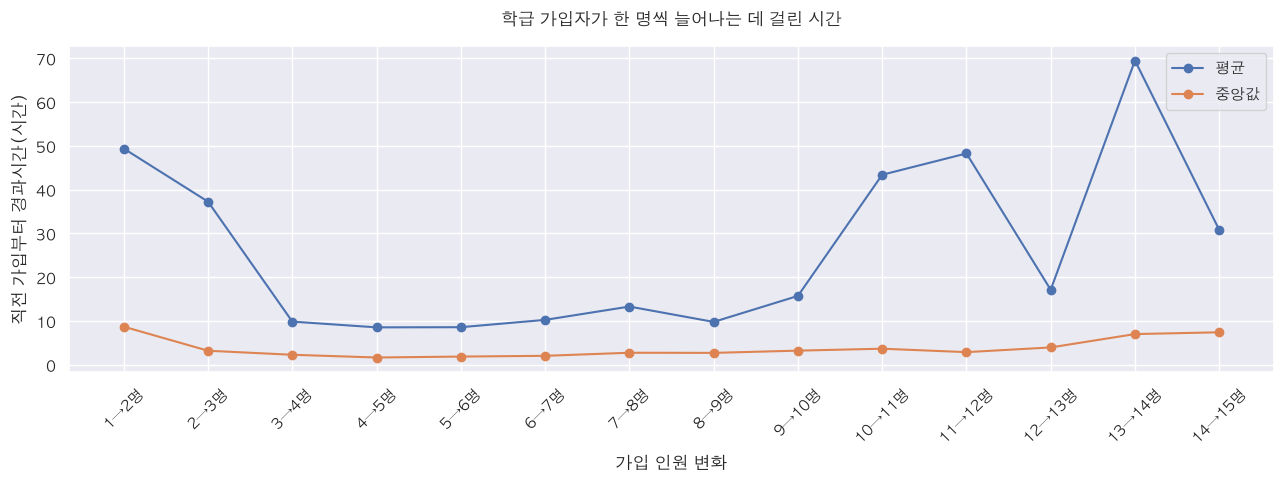

In [31]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    step_summary['가입 단계'],
    step_summary['평균경과시간'],
    marker='o',
    label='평균',
)

ax.plot(
    step_summary['가입 단계'],
    step_summary['중앙경과시간'],
    marker='o',
    label='중앙값',
)

ax.set_title('학급 가입자가 한 명씩 늘어나는 데 걸린 시간', pad=15)
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('직전 가입부터 경과시간(시간)')
ax.legend()
ax.tick_params(axis='x', labelrotation=45)

fig.tight_layout()
plt.show()

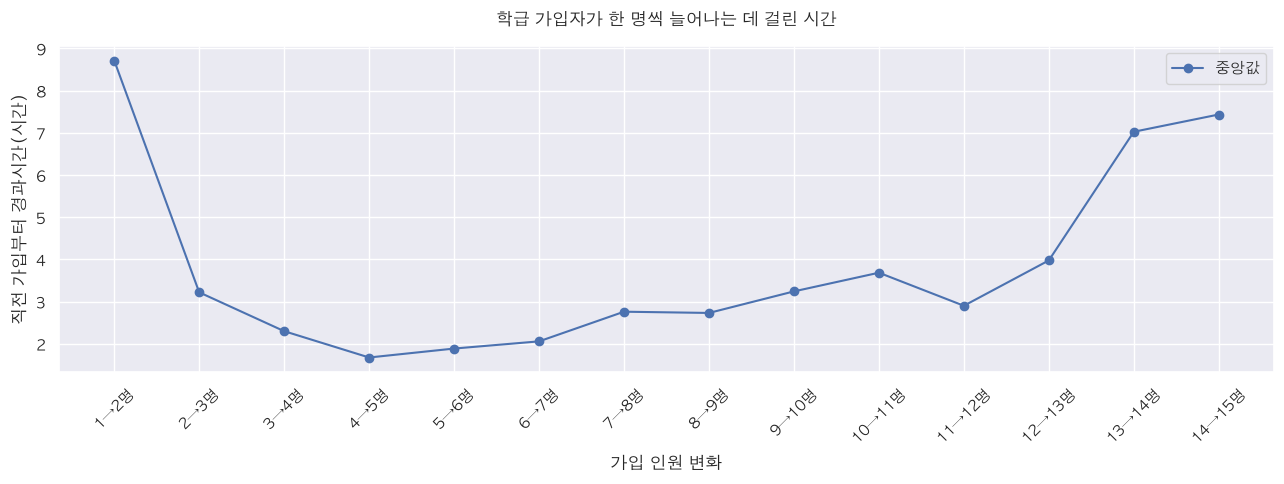

In [32]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    step_summary['가입 단계'],
    step_summary['중앙경과시간'],
    marker='o',
    label='중앙값',
)

ax.set_title('학급 가입자가 한 명씩 늘어나는 데 걸린 시간', pad=15)
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('직전 가입부터 경과시간(시간)')
ax.legend()
ax.tick_params(axis='x', labelrotation=45)

fig.tight_layout()
plt.show()

In [33]:
MIN_FINAL_USERS = 15

fixed_steps = (
    df[['group_id', 'user_id', 'signup_date']]
    .dropna(subset=['group_id', 'user_id', 'signup_date'])
    .sort_values(['group_id', 'signup_date'], kind='stable')
    .drop_duplicates(['group_id', 'user_id'], keep='first')
    .copy()
)

group_sizes = fixed_steps.groupby('group_id')['user_id'].nunique()
fixed_group_ids = group_sizes[
    group_sizes >= MIN_FINAL_USERS
].index

fixed_steps = fixed_steps.loc[
    fixed_steps['group_id'].isin(fixed_group_ids)
].copy()

fixed_steps['가입 순번'] = (
    fixed_steps.groupby('group_id').cumcount() + 1
)

fixed_steps['경과시간(시간)'] = (
    fixed_steps.groupby('group_id')['signup_date']
    .diff()
    .dt.total_seconds()
    .div(3600)
)

fixed_steps = fixed_steps.loc[
    fixed_steps['가입 순번'].between(2, 15)
]

print(f'분석 대상: 가입자 15명 이상인 학급 {len(fixed_group_ids):,}개')

분석 대상: 가입자 15명 이상인 학급 181개


,도달 인원,관측학급수,평균경과시간,중앙경과시간,가입 단계
0,2,181,35.61,4.83,1→2명
1,3,181,14.18,1.73,2→3명
2,4,181,8.77,2.33,3→4명
3,5,181,5.84,1.20,4→5명
4,6,181,6.64,1.46,5→6명
5,7,181,6.10,1.16,6→7명
6,8,181,6.21,1.68,7→8명
7,9,181,5.42,1.68,8→9명
8,10,181,5.84,1.66,9→10명
9,11,181,7.63,1.73,10→11명


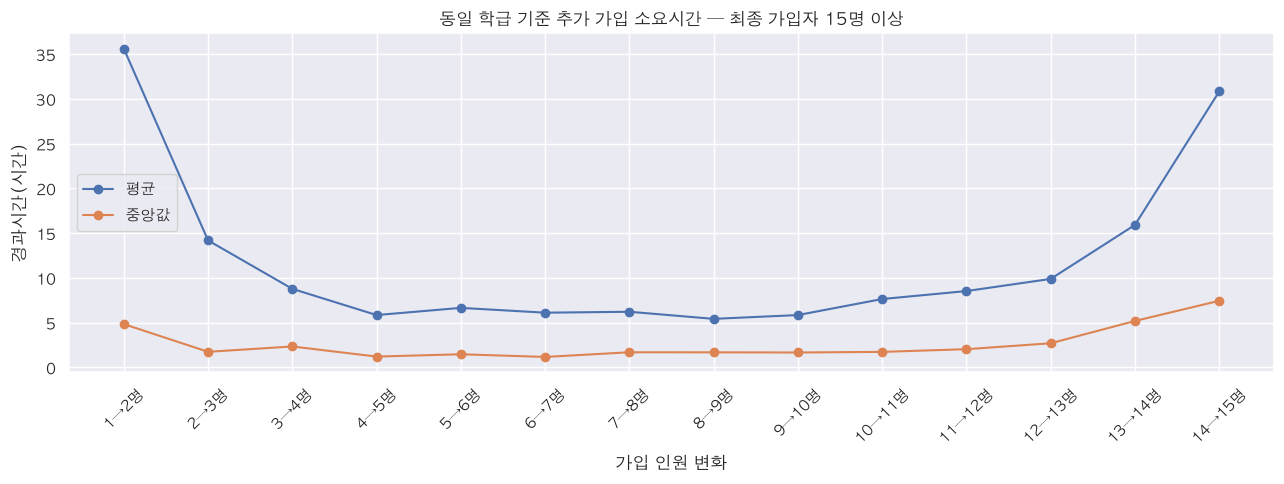

In [34]:
fixed_step_summary = (
    fixed_steps.groupby('가입 순번')
    .agg(
        관측학급수=('group_id', 'nunique'),
        평균경과시간=('경과시간(시간)', 'mean'),
        중앙경과시간=('경과시간(시간)', 'median'),
    )
    .reindex(range(2, 16))
    .rename_axis('도달 인원')
    .reset_index()
)

fixed_step_summary['가입 단계'] = (
    fixed_step_summary['도달 인원']
    .map(lambda n: f'{n - 1}→{n}명')
)

display(fixed_step_summary.round(2))

fig, ax = plt.subplots(figsize=(13, 5))

for column, label in [
    ('평균경과시간', '평균'),
    ('중앙경과시간', '중앙값'),
]:
    ax.plot(
        fixed_step_summary['가입 단계'],
        fixed_step_summary[column],
        marker='o',
        label=label,
    )

ax.set_title('동일 학급 기준 추가 가입 소요시간 — 최종 가입자 15명 이상')
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('경과시간(시간)')
ax.tick_params(axis='x', labelrotation=45)
ax.legend()

fig.tight_layout()
plt.show()

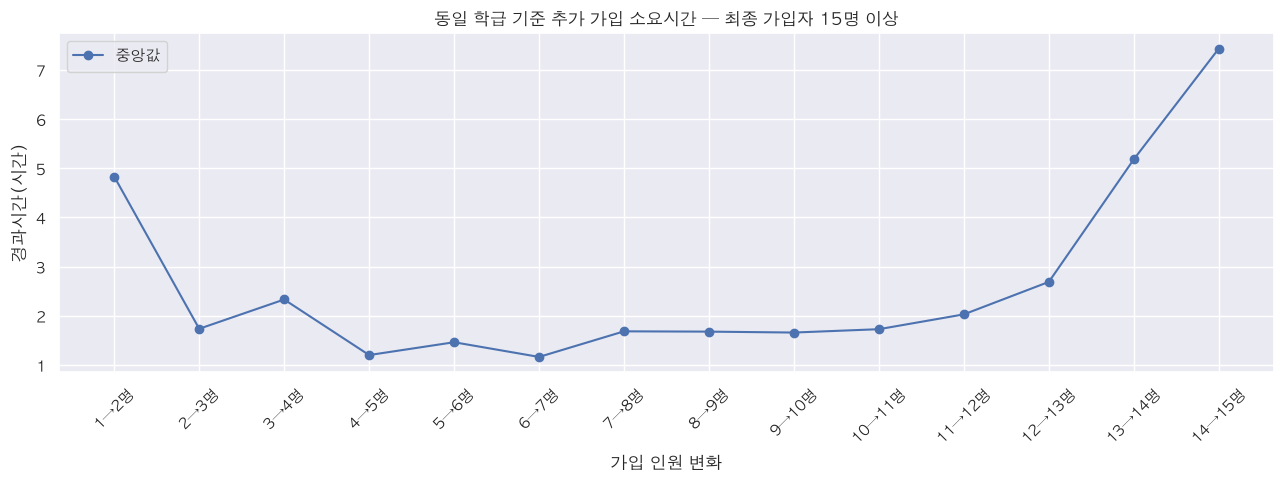

In [35]:
fig, ax = plt.subplots(figsize=(13, 5))

for column, label in [
    ('중앙경과시간', '중앙값'),
]:
    ax.plot(
        fixed_step_summary['가입 단계'],
        fixed_step_summary[column],
        marker='o',
        label=label,
    )

ax.set_title('동일 학급 기준 추가 가입 소요시간 — 최종 가입자 15명 이상')
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('경과시간(시간)')
ax.tick_params(axis='x', labelrotation=45)
ax.legend()

fig.tight_layout()
plt.show()

In [41]:
# 유저별 최초 가입 시각
signup_times = (
    df[['user_id', 'signup_date']]
    .dropna()
    .groupby('user_id')['signup_date']
    .min()
)

# 집계용 시각만 한국 시간으로 변환
signup_hour = (
    pd.to_datetime(signup_times, utc=True)
    .dt.tz_convert('Asia/Seoul')
    .dt.hour
)

hourly_signup = (
    signup_hour.value_counts()
    .reindex(range(24), fill_value=0)
    .rename_axis('가입 시간대')
    .reset_index(name='가입자 수')
)

hourly_signup['비중(%)'] = (
    (hourly_signup['가입자 수'] / len(signup_times) * 100).round(2)
    if len(signup_times) else float('nan')
)

display(hourly_signup)

,가입 시간대,가입자 수,비중(%)
0,0,358,7.03
1,1,162,3.18
2,2,76,1.49
3,3,22,0.43
4,4,14,0.28
5,5,5,0.10
6,6,20,0.39
7,7,69,1.36
8,8,153,3.01
9,9,87,1.71


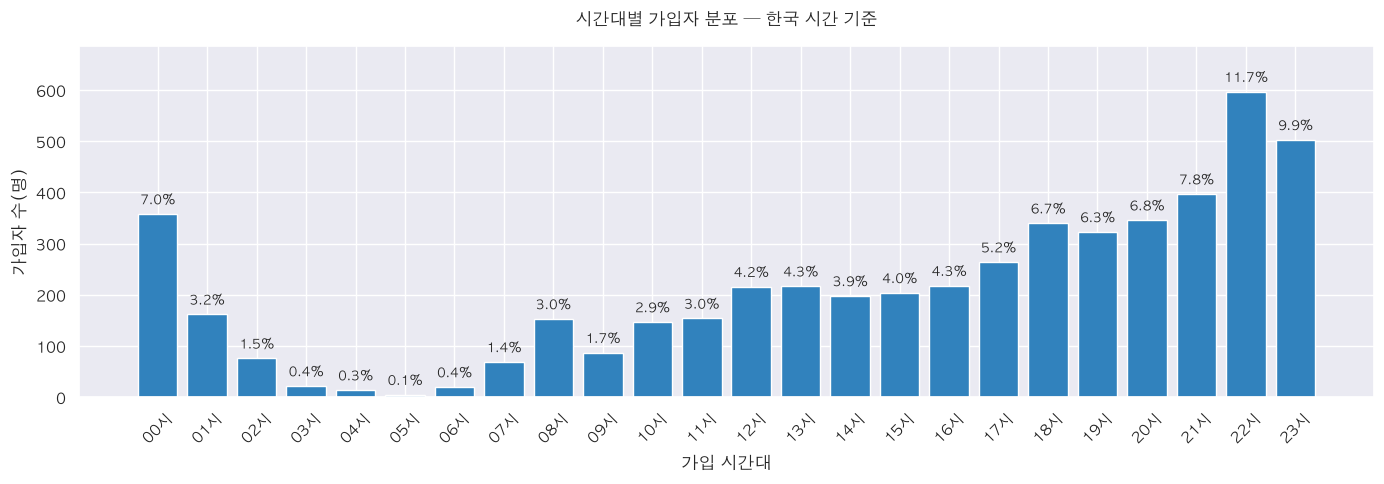

In [42]:
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    hourly_signup['가입 시간대'],
    hourly_signup['가입자 수'],
    color='#3182bd',
)

ax.bar_label(
    bars,
    labels=[
        f'{share:.1f}%' if pd.notna(share) else ''
        for share in hourly_signup['비중(%)']
    ],
    padding=4,
    fontsize=9,
)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{hour:02d}시' for hour in range(24)], rotation=45)
ax.set_title('시간대별 가입자 분포 — 한국 시간 기준', pad=15)
ax.set_xlabel('가입 시간대')
ax.set_ylabel('가입자 수(명)')
ax.margins(y=0.15)

fig.tight_layout()
plt.show()

In [43]:
signup_times_utc = (
    df[['user_id', 'signup_date']]
    .dropna()
    .groupby('user_id')['signup_date']
    .min()
)

hourly_signup_utc = (
    pd.to_datetime(signup_times_utc, utc=True)
    .dt.hour
    .value_counts()
    .reindex(range(24), fill_value=0)
    .rename_axis('가입 시간대')
    .reset_index(name='가입자 수')
)

hourly_signup_utc['비중(%)'] = (
    (hourly_signup_utc['가입자 수'] / len(signup_times_utc) * 100).round(2)
    if len(signup_times_utc) else float('nan')
)

display(hourly_signup_utc)

,가입 시간대,가입자 수,비중(%)
0,0,87,1.71
1,1,147,2.89
2,2,154,3.03
3,3,216,4.24
4,4,217,4.26
5,5,198,3.89
6,6,204,4.01
7,7,218,4.28
8,8,264,5.19
9,9,340,6.68


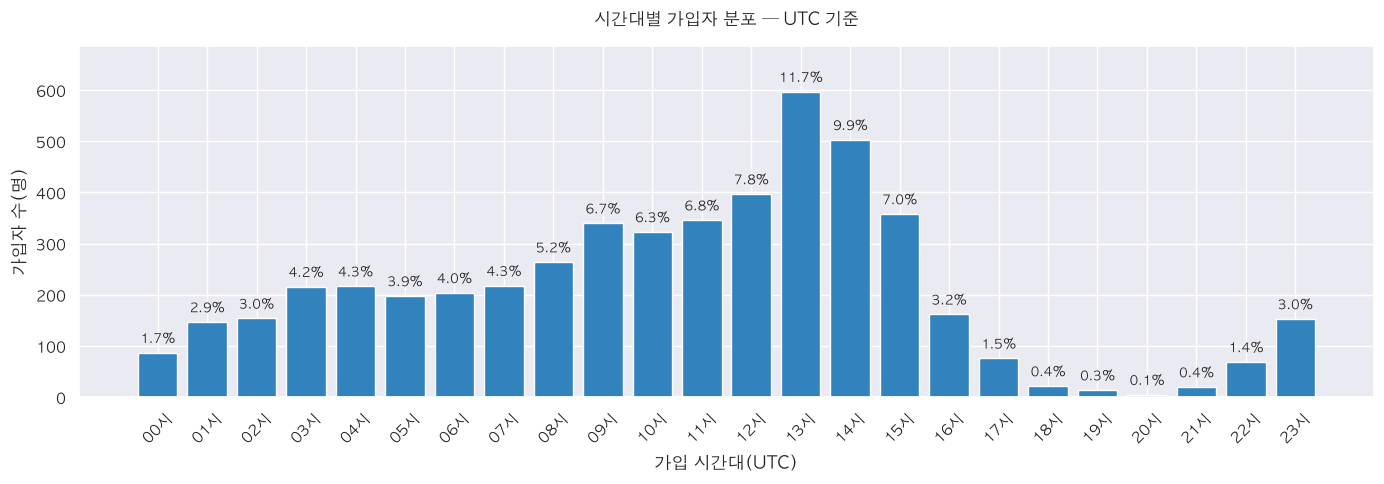

In [44]:
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    hourly_signup_utc['가입 시간대'],
    hourly_signup_utc['가입자 수'],
    color='#3182bd',
)

ax.bar_label(
    bars,
    labels=[
        f'{share:.1f}%' if pd.notna(share) else ''
        for share in hourly_signup_utc['비중(%)']
    ],
    padding=4,
    fontsize=9,
)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{hour:02d}시' for hour in range(24)], rotation=45)
ax.set_title('시간대별 가입자 분포 — UTC 기준', pad=15)
ax.set_xlabel('가입 시간대(UTC)')
ax.set_ylabel('가입자 수(명)')
ax.margins(y=0.15)

fig.tight_layout()
plt.show()

In [45]:
# 유저별 최초 가입 시각
monthly_hour_data = (
    df[['user_id', 'signup_date']]
    .dropna()
    .groupby('user_id', as_index=False)['signup_date']
    .min()
)

signup_datetime = (
    pd.to_datetime(monthly_hour_data['signup_date'], utc=True)
    .dt.tz_convert('Asia/Seoul')
)

monthly_hour_data['가입월'] = signup_datetime.dt.strftime('%Y-%m')
monthly_hour_data['가입시간'] = signup_datetime.dt.hour

monthly_hour_data['가입월'] = signup_datetime.dt.strftime('%Y-%m')
monthly_hour_data['가입시간'] = signup_datetime.dt.hour

# 월 × 시간별 가입자 수
monthly_hour_counts = (
    monthly_hour_data.groupby(['가입월', '가입시간'])['user_id']
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
    .sort_index()
)

# 각 월의 합계가 100%가 되도록 계산
monthly_hour_share = (
    monthly_hour_counts
    .div(monthly_hour_counts.sum(axis=1), axis=0)
    * 100
)

display(monthly_hour_counts)

가입시간,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
가입월,,,,,,,,,,,,,,,,,,,,,
2023-04,23,23,31,6,2,1,1,2,7,8,...,10,14,14,16,12,22,12,12,56,32
2023-05,332,137,43,14,11,4,19,66,145,79,...,187,188,201,243,327,299,329,377,536,467
2023-06,1,0,2,2,0,0,0,0,1,0,...,1,2,2,4,1,2,4,4,4,1
2023-07,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,1,1
2023-08,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2023-09,1,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2023-10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2023-11,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2023-12,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


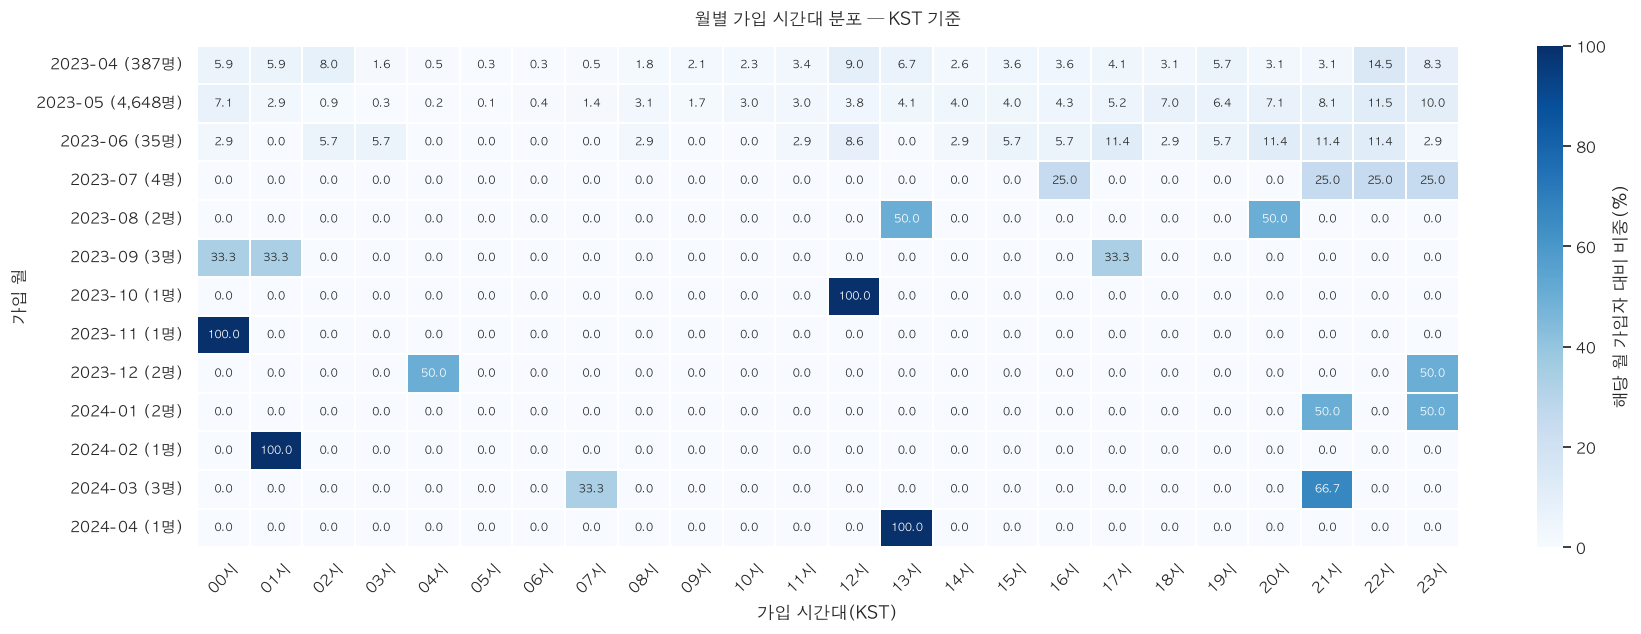

In [46]:
fig, ax = plt.subplots(
    figsize=(18, max(5, len(monthly_hour_share) * 0.5))
)

sns.heatmap(
    monthly_hour_share,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    linewidths=0.3,
    annot_kws={'fontsize': 8},
    cbar_kws={'label': '해당 월 가입자 대비 비중(%)'},
    ax=ax,
)

# 월별 표본 규모도 함께 표시
ax.set_yticklabels(
    [
        f'{month} ({int(count):,}명)'
        for month, count in monthly_hour_counts.sum(axis=1).items()
    ],
    rotation=0,
)

ax.set_xticklabels([f'{hour:02d}시' for hour in range(24)], rotation=45)
ax.set_title('월별 가입 시간대 분포 — KST 기준', pad=15)
ax.set_xlabel('가입 시간대(KST)')
ax.set_ylabel('가입 월')

fig.tight_layout()
plt.show()

In [52]:
# 학급별 고유 가입자 수
group_sizes = (
    df[['group_id', 'user_id']]
    .dropna()
    .groupby('group_id')['user_id']
    .nunique()
)

records = []

for n in range(1, 15):
    reached_n = group_sizes.ge(n).sum()
    reached_next = group_sizes.ge(n + 1).sum()

    records.append({
        '가입 단계': f'{n}→{n + 1}명',
        'N명 이상 학급 수': reached_n,
        'N+1명 이상 학급 수': reached_next,
        '다음 인원 도달률(%)': (
            reached_next / reached_n * 100
            if reached_n else float('nan')
        ),
    })

group_progression = pd.DataFrame(records)

display(group_progression.round(2))

,가입 단계,N명 이상 학급 수,N+1명 이상 학급 수,다음 인원 도달률(%)
0,1→2명,353,344,97.45
1,2→3명,344,336,97.67
2,3→4명,336,325,96.73
3,4→5명,325,322,99.08
4,5→6명,322,318,98.76
5,6→7명,318,313,98.43
6,7→8명,313,306,97.76
7,8→9명,306,296,96.73
8,9→10명,296,289,97.64
9,10→11명,289,276,95.50


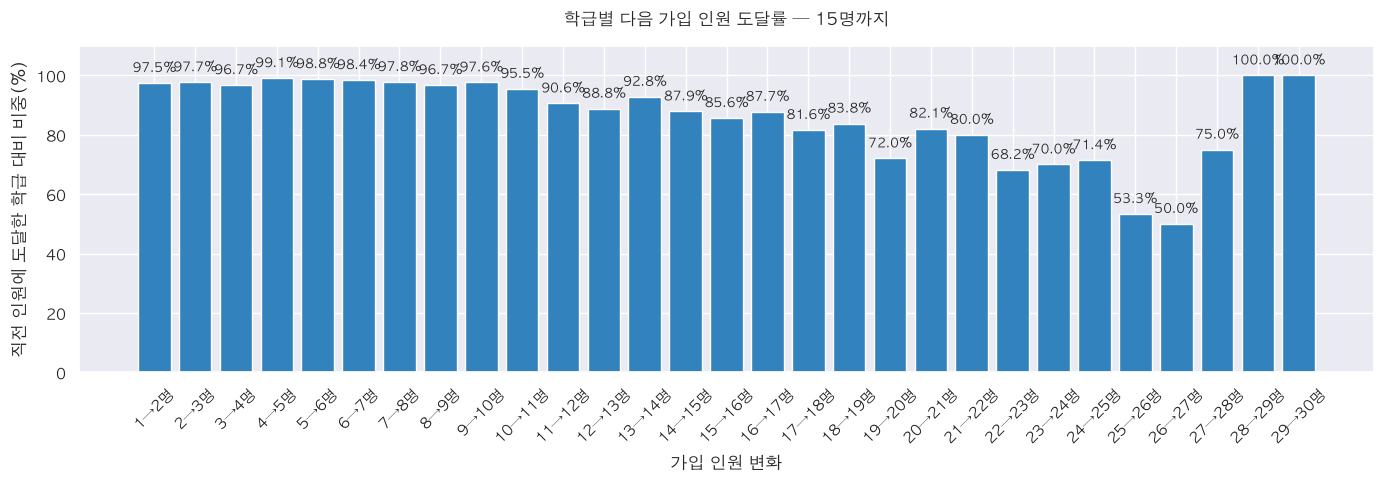

In [51]:
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    group_progression['가입 단계'],
    group_progression['다음 인원 도달률(%)'],
    color='#3182bd',
)

ax.bar_label(
    bars,
    labels=[
        f'{rate:.1f}%' if pd.notna(rate) else ''
        for rate in group_progression['다음 인원 도달률(%)']
    ],
    padding=5,
    fontsize=9,
)

ax.set_title('학급별 다음 가입 인원 도달률 — 15명까지', pad=15)
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('직전 인원에 도달한 학급 대비 비중(%)')
ax.set_ylim(0, 110)
ax.tick_params(axis='x', labelrotation=45)

fig.tight_layout()
plt.show()

In [53]:
# 학급별 고유 가입자 수
group_sizes = (
    df[['group_id', 'user_id']]
    .dropna()
    .groupby('group_id')['user_id']
    .nunique()
)

records = []

for n in range(1, 15):
    reached_n = group_sizes.ge(1).sum()
    reached_next = group_sizes.ge(n + 1).sum()

    records.append({
        '가입 단계': f'{n}→{n + 1}명',
        'N명 이상 학급 수': reached_n,
        'N+1명 이상 학급 수': reached_next,
        '다음 인원 도달률(%)': (
            reached_next / reached_n * 100
            if reached_n else float('nan')
        ),
    })

group_progression = pd.DataFrame(records)

display(group_progression.round(2))

,가입 단계,N명 이상 학급 수,N+1명 이상 학급 수,다음 인원 도달률(%)
0,1→2명,353,344,97.45
1,2→3명,353,336,95.18
2,3→4명,353,325,92.07
3,4→5명,353,322,91.22
4,5→6명,353,318,90.08
5,6→7명,353,313,88.67
6,7→8명,353,306,86.69
7,8→9명,353,296,83.85
8,9→10명,353,289,81.87
9,10→11명,353,276,78.19


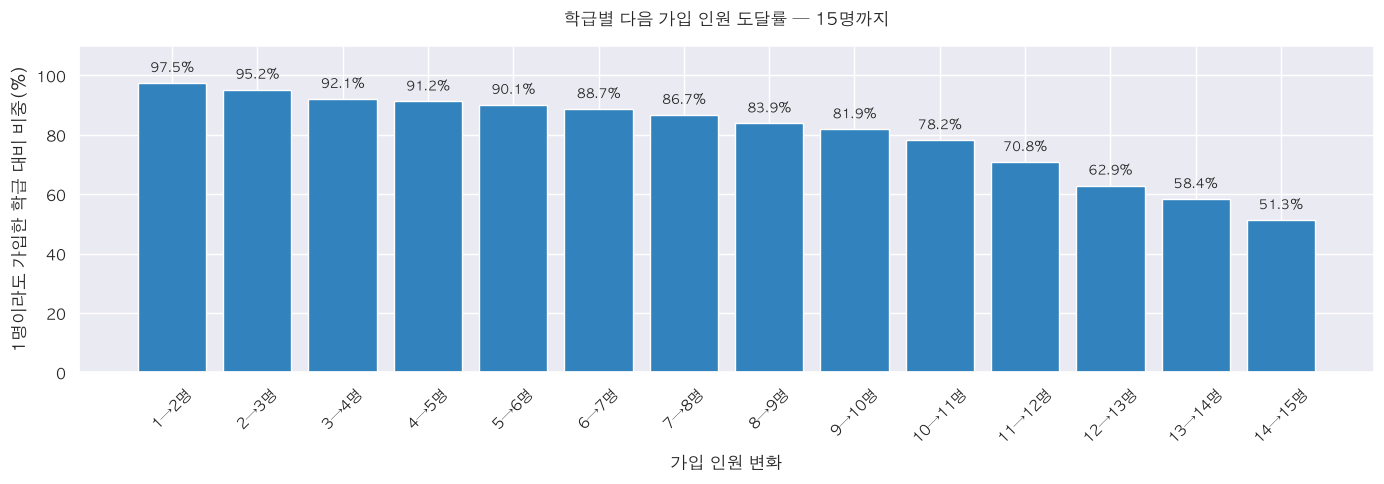

In [54]:
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    group_progression['가입 단계'],
    group_progression['다음 인원 도달률(%)'],
    color='#3182bd',
)

ax.bar_label(
    bars,
    labels=[
        f'{rate:.1f}%' if pd.notna(rate) else ''
        for rate in group_progression['다음 인원 도달률(%)']
    ],
    padding=5,
    fontsize=9,
)

ax.set_title('학급별 다음 가입 인원 도달률 — 15명까지', pad=15)
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('1명이라도 가입한 학급 대비 비중(%)')
ax.set_ylim(0, 110)
ax.tick_params(axis='x', labelrotation=45)

fig.tight_layout()
plt.show()

# 가입이 촉진되는 임계점 확인

In [55]:
# 1. 학급별·사용자별 최초 가입 시각 정리
group_user_signup = (
    df[['group_id', 'user_id', 'signup_date']]
    .dropna(subset=['group_id', 'user_id', 'signup_date'])
    .assign(
        signup_datetime=lambda x: pd.to_datetime(
            x['signup_date'],
            utc=True,
            errors='coerce',
        )
    )
    .dropna(subset=['signup_datetime'])
    .groupby(['group_id', 'user_id'], as_index=False)
    .agg(signup_datetime=('signup_datetime', 'min'))
)

# 데이터에서 관측 가능한 마지막 가입 시각
observation_end = group_user_signup['signup_datetime'].max()
followup_period = pd.Timedelta(days=30)

In [56]:
# 2. 학급별 가입 순서와 최초 가입 후 경과시간 계산
group_signup_steps = (
    group_user_signup
    .sort_values(['group_id', 'signup_datetime', 'user_id'])
    .copy()
)

group_signup_steps['가입순번'] = (
    group_signup_steps.groupby('group_id').cumcount() + 1
)

group_signup_steps['최초가입시각'] = (
    group_signup_steps
    .groupby('group_id')['signup_datetime']
    .transform('min')
)

group_signup_steps['최초가입후경과시간'] = (
    group_signup_steps['signup_datetime']
    - group_signup_steps['최초가입시각']
)

In [57]:
# 3. 최초 가입 후 30일을 온전히 관찰할 수 있는 학급만 선정
eligible_group_ids = (
    group_signup_steps.loc[
        group_signup_steps['최초가입시각'].le(
            observation_end - followup_period
        ),
        'group_id',
    ]
    .unique()
)

eligible_steps = (
    group_signup_steps[
        group_signup_steps['group_id'].isin(eligible_group_ids)
    ]
    .copy()
)

print(f'전체 학급 수: {group_signup_steps["group_id"].nunique():,}개')
print(f'30일 관찰 가능 학급 수: {len(eligible_group_ids):,}개')
print(f'관찰 종료 시각: {observation_end}')

전체 학급 수: 353개
30일 관찰 가능 학급 수: 353개
관찰 종료 시각: 2024-04-22 04:54:45.332573+00:00


In [58]:
# 4. 최초 가입부터 24시간 미만에 가입한 고유 사용자 수
initial_24h_users = (
    eligible_steps.loc[
        eligible_steps['최초가입후경과시간'].lt(
            pd.Timedelta(hours=24)
        )
    ]
    .groupby('group_id')['user_id']
    .nunique()
    .rename('초기24시간가입자수')
)

In [59]:
# 5. 학급별 15번째 가입 도달시간
reached_15 = (
    eligible_steps.loc[
        eligible_steps['가입순번'].eq(15),
        ['group_id', '최초가입후경과시간'],
    ]
    .set_index('group_id')
    .rename(columns={'최초가입후경과시간': '15명도달시간'})
)

# 30일 안에 15명에 도달한 경우만 인정
reached_15['30일내15명도달'] = (
    reached_15['15명도달시간'].le(followup_period)
)

reached_15.loc[
    ~reached_15['30일내15명도달'],
    '15명도달시간',
] = pd.NaT

In [60]:
# 6. 학급 단위 분석 데이터 생성
group_growth = (
    initial_24h_users
    .to_frame()
    .join(reached_15, how='left')
)

group_growth['30일내15명도달'] = (
    group_growth['30일내15명도달']
    .fillna(False)
    .astype(bool)
)

group_growth['15명도달시간(시간)'] = (
    group_growth['15명도달시간'].dt.total_seconds() / 3600
)

group_growth['초기 24시간 가입자'] = pd.cut(
    group_growth['초기24시간가입자수'],
    bins=[0, 1, 2, 3, 4, float('inf')],
    labels=['1명', '2명', '3명', '4명', '5명 이상'],
)

In [61]:
# 7. 초기 가입자 구간별 결과 집계
initial_growth_summary = (
    group_growth
    .groupby('초기 24시간 가입자', observed=False)
    .agg(
        학급수=('30일내15명도달', 'size'),
        도달학급수=('30일내15명도달', 'sum'),
        도달시간평균=('15명도달시간(시간)', 'mean'),
        도달시간중앙값=('15명도달시간(시간)', 'median'),
    )
    .reset_index()
)

initial_growth_summary['30일 내 15명 도달률(%)'] = (
    initial_growth_summary['도달학급수']
    / initial_growth_summary['학급수']
    * 100
)

initial_growth_summary[
    [
        '30일 내 15명 도달률(%)',
        '도달시간평균',
        '도달시간중앙값',
    ]
] = initial_growth_summary[
    [
        '30일 내 15명 도달률(%)',
        '도달시간평균',
        '도달시간중앙값',
    ]
].round(2)

display(
    initial_growth_summary[
        [
            '초기 24시간 가입자',
            '학급수',
            '도달학급수',
            '30일 내 15명 도달률(%)',
            '도달시간평균',
            '도달시간중앙값',
        ]
    ]
)

,초기 24시간 가입자,학급수,도달학급수,30일 내 15명 도달률(%),도달시간평균,도달시간중앙값
0,1명,123,50,40.65,237.02,202.60
1,2명,35,19,54.29,171.49,139.03
2,3명,42,21,50.00,159.79,120.62
3,4명,22,13,59.09,232.53,162.54
4,5명 이상,131,77,58.78,102.24,73.25


In [62]:
# 초기 24시간 가입자가 정확히 1~15명인 학급만 비교
group_growth_exact = (
    group_growth[
        group_growth['초기24시간가입자수'].between(1, 15)
    ]
    .copy()
)

In [63]:
# 초기 24시간 가입자 수별 결과 집계
initial_growth_summary_exact = (
    group_growth_exact
    .groupby('초기24시간가입자수')
    .agg(
        학급수=('30일내15명도달', 'size'),
        도달학급수=('30일내15명도달', 'sum'),
        도달시간평균=('15명도달시간(시간)', 'mean'),
        도달시간중앙값=('15명도달시간(시간)', 'median'),
    )
    .reindex(range(1, 16))
    .rename_axis('초기 24시간 가입자 수')
    .reset_index()
)

initial_growth_summary_exact['학급수'] = (
    initial_growth_summary_exact['학급수']
    .fillna(0)
    .astype(int)
)

initial_growth_summary_exact['도달학급수'] = (
    initial_growth_summary_exact['도달학급수']
    .fillna(0)
    .astype(int)
)

initial_growth_summary_exact['30일 내 15명 도달률(%)'] = (
    initial_growth_summary_exact['도달학급수']
    / initial_growth_summary_exact['학급수'].replace(0, float('nan'))
    * 100
)

round_columns = [
    '30일 내 15명 도달률(%)',
    '도달시간평균',
    '도달시간중앙값',
]

initial_growth_summary_exact[round_columns] = (
    initial_growth_summary_exact[round_columns].round(2)
)

display(initial_growth_summary_exact)

,초기 24시간 가입자 수,학급수,도달학급수,도달시간평균,도달시간중앙값,30일 내 15명 도달률(%)
0,1,123,50,237.02,202.60,40.65
1,2,35,19,171.49,139.03,54.29
2,3,42,21,159.79,120.62,50.00
3,4,22,13,232.53,162.54,59.09
4,5,20,10,147.57,117.50,50.00
5,6,20,8,161.73,142.90,40.00
6,7,21,14,163.62,102.98,66.67
7,8,12,6,91.00,92.11,50.00
8,9,12,5,112.11,104.83,41.67
9,10,8,4,66.47,67.77,50.00


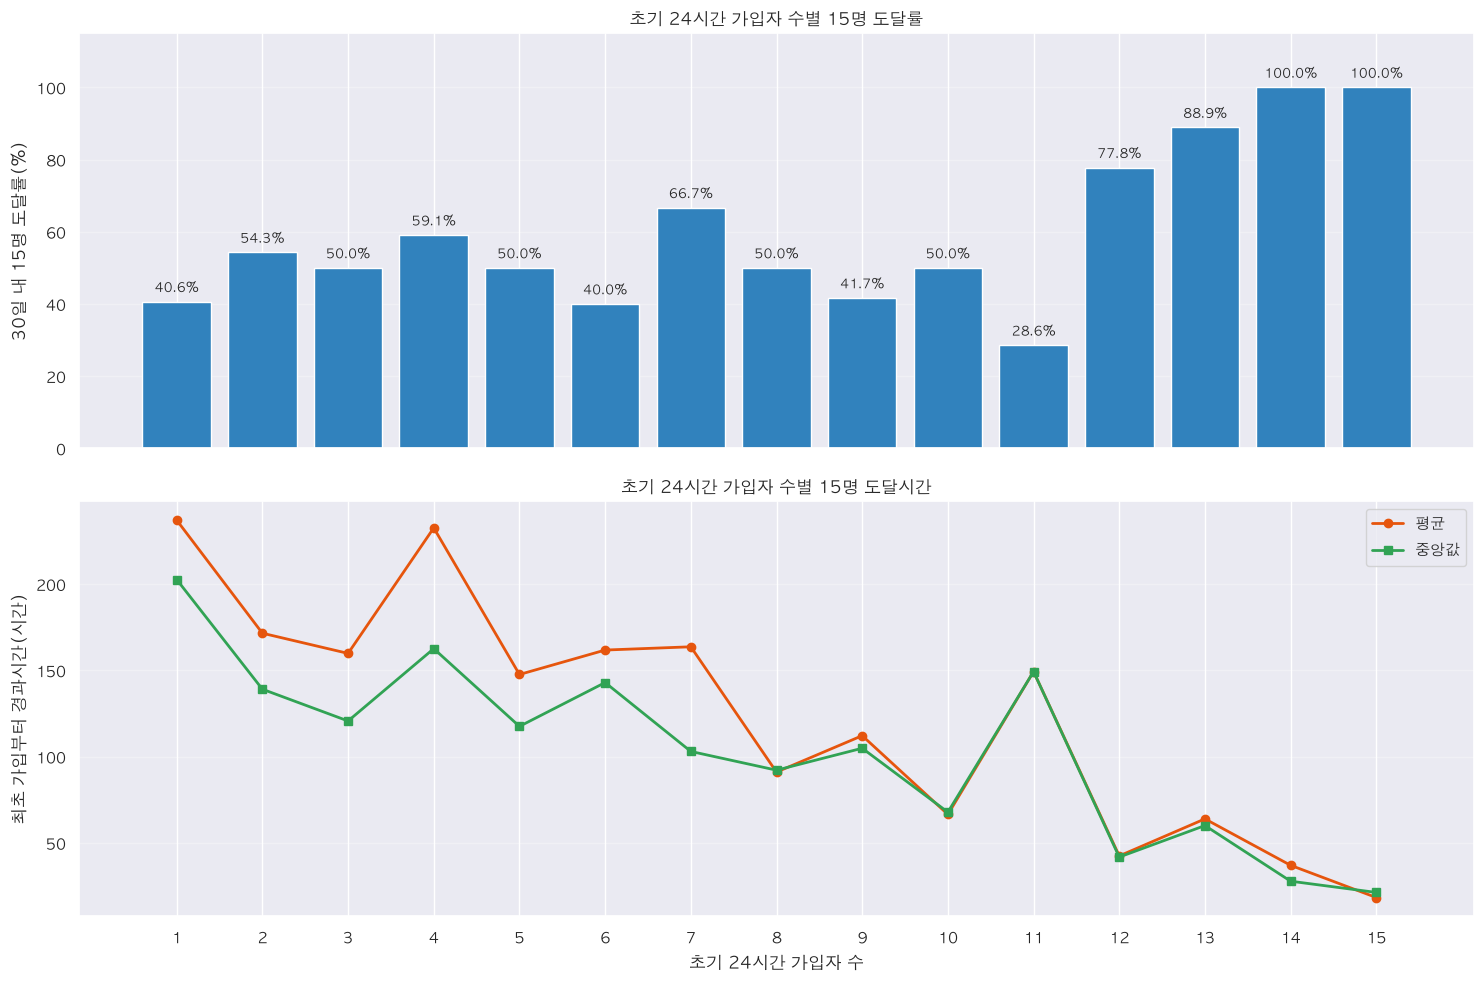

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

x = initial_growth_summary_exact['초기 24시간 가입자 수']

# 15명 도달률
bars = axes[0].bar(
    x,
    initial_growth_summary_exact['30일 내 15명 도달률(%)'],
    color='#3182bd',
)

axes[0].bar_label(
    bars,
    labels=[
        f'{value:.1f}%' if pd.notna(value) else ''
        for value in initial_growth_summary_exact[
            '30일 내 15명 도달률(%)'
        ]
    ],
    padding=4,
    fontsize=9,
)

axes[0].set_title('초기 24시간 가입자 수별 15명 도달률')
axes[0].set_ylabel('30일 내 15명 도달률(%)')
axes[0].margins(y=0.15)
axes[0].grid(axis='y', alpha=0.3)

# 15명 도달시간
axes[1].plot(
    x,
    initial_growth_summary_exact['도달시간평균'],
    marker='o',
    linewidth=2,
    label='평균',
    color='#e6550d',
)

axes[1].plot(
    x,
    initial_growth_summary_exact['도달시간중앙값'],
    marker='s',
    linewidth=2,
    label='중앙값',
    color='#31a354',
)

axes[1].set_title('초기 24시간 가입자 수별 15명 도달시간')
axes[1].set_xlabel('초기 24시간 가입자 수')
axes[1].set_ylabel('최초 가입부터 경과시간(시간)')
axes[1].set_xticks(range(1, 16))
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

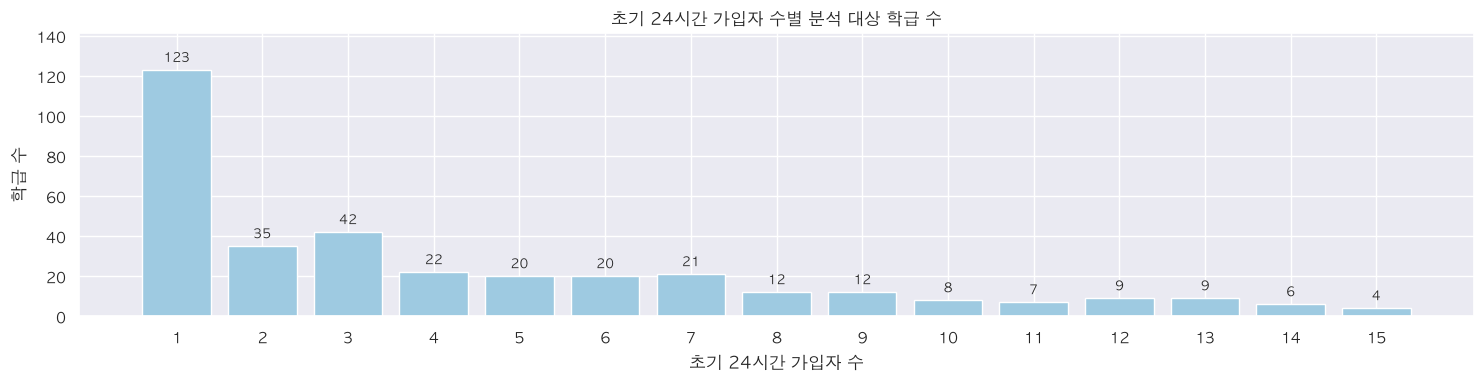

In [65]:
fig, ax = plt.subplots(figsize=(15, 4))

bars = ax.bar(
    x,
    initial_growth_summary_exact['학급수'],
    color='#9ecae1',
)

ax.bar_label(
    bars,
    labels=[
        f'{count:,}'
        for count in initial_growth_summary_exact['학급수']
    ],
    padding=3,
    fontsize=9,
)

ax.set_title('초기 24시간 가입자 수별 분석 대상 학급 수')
ax.set_xlabel('초기 24시간 가입자 수')
ax.set_ylabel('학급 수')
ax.set_xticks(range(1, 16))
ax.margins(y=0.15)

fig.tight_layout()
plt.show()

In [66]:
# 분석 기준
initial_window = pd.Timedelta(hours=24)
additional_window = pd.Timedelta(days=7)
required_observation = initial_window + additional_window

observation_end = group_signup_steps['signup_datetime'].max()

In [67]:
# 최초 가입 후 8일을 온전히 관찰할 수 있는 학급만 선정
additional_eligible_groups = (
    group_signup_steps.loc[
        group_signup_steps['최초가입시각'].le(
            observation_end - required_observation
        ),
        'group_id',
    ]
    .unique()
)

additional_steps = (
    group_signup_steps[
        group_signup_steps['group_id'].isin(
            additional_eligible_groups
        )
    ]
    .copy()
)

print(
    f'분석 대상 학급 수: '
    f'{len(additional_eligible_groups):,}개'
)

분석 대상 학급 수: 353개


In [68]:
# 초기 24시간 가입자 수
initial_counts = (
    additional_steps.loc[
        additional_steps['최초가입후경과시간'].lt(initial_window)
    ]
    .groupby('group_id')['user_id']
    .nunique()
    .rename('초기24시간가입자수')
)

# 초기 24시간 이후부터 7일 동안 발생한 추가 가입
after_initial = (
    additional_steps.loc[
        additional_steps['최초가입후경과시간'].ge(initial_window)
        & additional_steps['최초가입후경과시간'].le(
            required_observation
        )
    ]
    .copy()
)

after_initial['추가가입순번'] = (
    after_initial.groupby('group_id').cumcount() + 1
)

In [69]:
# 7일 동안 추가로 가입한 사용자 수
additional_counts = (
    after_initial
    .groupby('group_id')['user_id']
    .nunique()
    .rename('7일추가가입자수')
)

# 초기 24시간 종료 후 다섯 번째 추가 가입자의 발생 시각
reached_additional_5 = (
    after_initial.loc[
        after_initial['추가가입순번'].eq(5),
        ['group_id', '최초가입후경과시간'],
    ]
    .set_index('group_id')
)

reached_additional_5['추가5명도달시간(시간)'] = (
    reached_additional_5['최초가입후경과시간']
    - initial_window
).dt.total_seconds() / 3600

reached_additional_5 = (
    reached_additional_5['추가5명도달시간(시간)']
)

In [70]:
additional_growth = (
    pd.DataFrame(index=additional_eligible_groups)
    .rename_axis('group_id')
    .join(initial_counts)
    .join(additional_counts)
    .join(reached_additional_5)
)

additional_growth['7일추가가입자수'] = (
    additional_growth['7일추가가입자수']
    .fillna(0)
    .astype(int)
)

additional_growth['7일내추가5명도달'] = (
    additional_growth['7일추가가입자수'].ge(5)
)

display(additional_growth.head())

,초기24시간가입자수,7일추가가입자수,추가5명도달시간(시간),7일내추가5명도달
group_id,,,,
23,1,0,NaN,False
233,1,1,NaN,False
321,1,0,NaN,False
356,1,1,NaN,False
519,1,0,NaN,False


In [71]:
additional_growth_summary = (
    additional_growth[
        additional_growth['초기24시간가입자수'].between(1, 15)
    ]
    .groupby('초기24시간가입자수')
    .agg(
        학급수=('7일내추가5명도달', 'size'),
        추가5명도달학급수=('7일내추가5명도달', 'sum'),
        평균추가가입자수=('7일추가가입자수', 'mean'),
        추가5명도달시간평균=('추가5명도달시간(시간)', 'mean'),
        추가5명도달시간중앙값=('추가5명도달시간(시간)', 'median'),
    )
    .reindex(range(1, 16))
    .rename_axis('초기 24시간 가입자 수')
    .reset_index()
)

additional_growth_summary['추가 5명 도달률(%)'] = (
    additional_growth_summary['추가5명도달학급수']
    / additional_growth_summary['학급수'].replace(
        0,
        float('nan'),
    )
    * 100
)

value_columns = [
    '평균추가가입자수',
    '추가 5명 도달률(%)',
    '추가5명도달시간평균',
    '추가5명도달시간중앙값',
]

additional_growth_summary[value_columns] = (
    additional_growth_summary[value_columns].round(2)
)

display(additional_growth_summary)

,초기 24시간 가입자 수,학급수,추가5명도달학급수,평균추가가입자수,추가5명도달시간평균,추가5명도달시간중앙값,추가 5명 도달률(%)
0,1,123,55,6.06,77.41,68.39,44.72
1,2,35,30,10.51,47.49,47.12,85.71
2,3,42,37,10.48,51.84,47.58,88.10
3,4,22,20,9.00,46.05,29.41,90.91
4,5,20,14,8.60,42.68,38.29,70.00
5,6,20,15,6.75,53.29,49.24,75.00
6,7,21,17,7.52,56.03,50.92,80.95
7,8,12,7,6.25,60.62,48.64,58.33
8,9,12,6,4.83,69.32,56.47,50.00
9,10,8,4,4.75,42.47,43.77,50.00


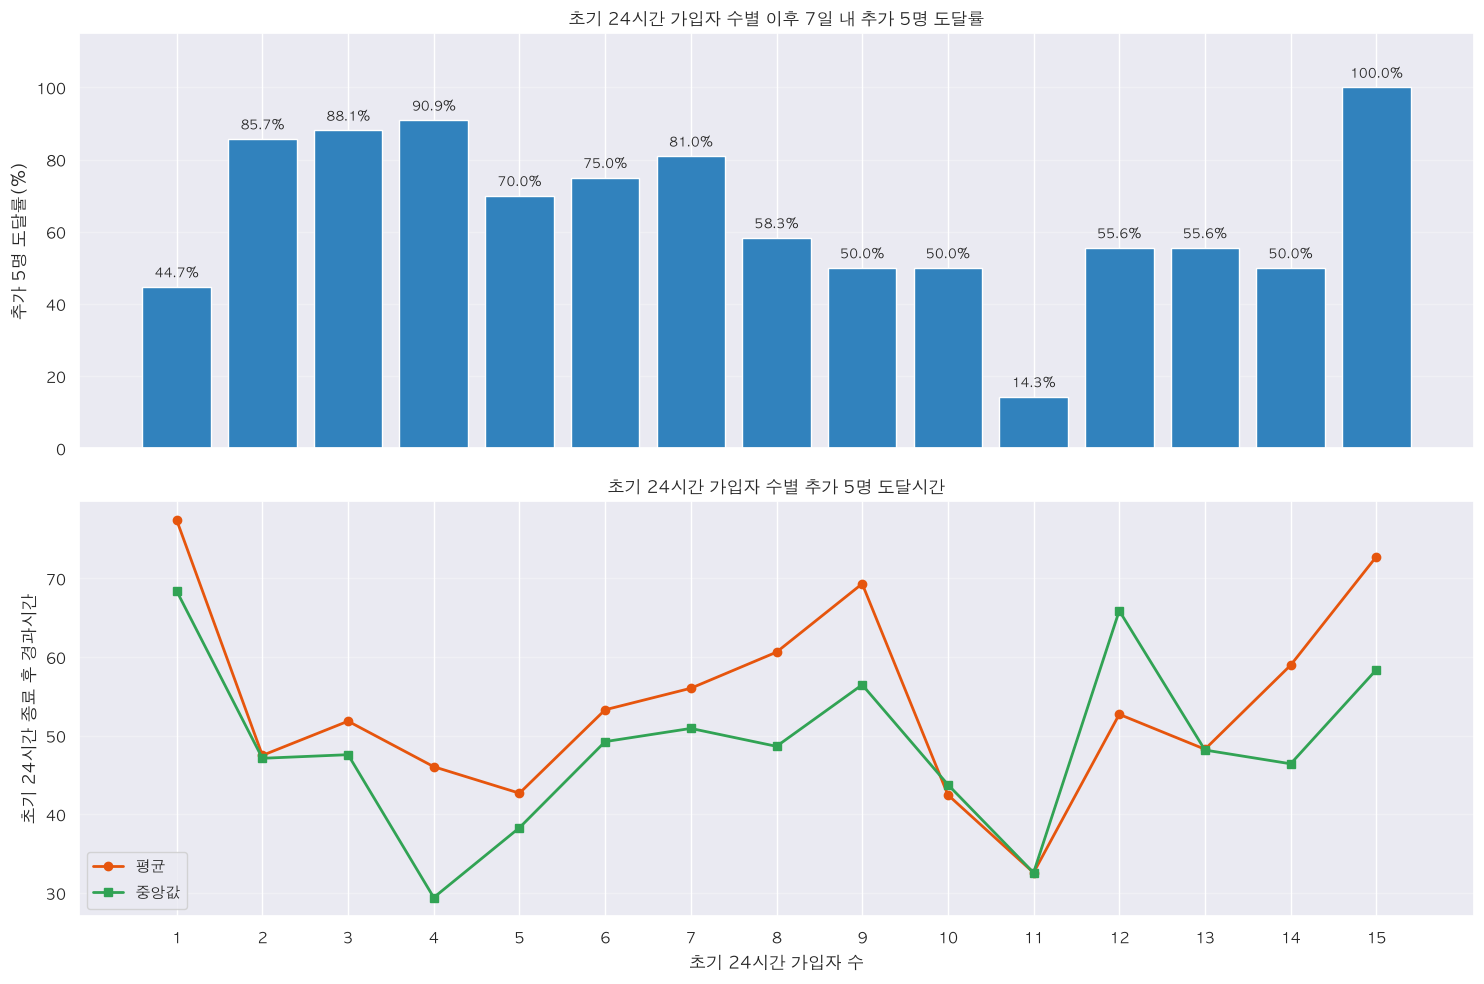

In [72]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

x = additional_growth_summary['초기 24시간 가입자 수']

# 추가 5명 도달률
bars = axes[0].bar(
    x,
    additional_growth_summary['추가 5명 도달률(%)'],
    color='#3182bd',
)

axes[0].bar_label(
    bars,
    labels=[
        f'{value:.1f}%' if pd.notna(value) else ''
        for value in additional_growth_summary[
            '추가 5명 도달률(%)'
        ]
    ],
    padding=4,
    fontsize=9,
)

axes[0].set_title(
    '초기 24시간 가입자 수별 이후 7일 내 추가 5명 도달률'
)
axes[0].set_ylabel('추가 5명 도달률(%)')
axes[0].margins(y=0.15)
axes[0].grid(axis='y', alpha=0.3)

# 추가 5명 도달시간
axes[1].plot(
    x,
    additional_growth_summary['추가5명도달시간평균'],
    marker='o',
    linewidth=2,
    label='평균',
    color='#e6550d',
)

axes[1].plot(
    x,
    additional_growth_summary['추가5명도달시간중앙값'],
    marker='s',
    linewidth=2,
    label='중앙값',
    color='#31a354',
)

axes[1].set_title(
    '초기 24시간 가입자 수별 추가 5명 도달시간'
)
axes[1].set_xlabel('초기 24시간 가입자 수')
axes[1].set_ylabel('초기 24시간 종료 후 경과시간')
axes[1].set_xticks(range(1, 16))
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

# 시간 경과에 따른 유저 인입

In [73]:
# 학급·사용자별 최초 가입 시각
group_user_signup = (
    df[['group_id', 'user_id', 'signup_date']]
    .dropna(subset=['group_id', 'user_id', 'signup_date'])
    .assign(
        signup_datetime=lambda x: pd.to_datetime(
            x['signup_date'],
            utc=True,
            errors='coerce',
        )
    )
    .dropna(subset=['signup_datetime'])
    .groupby(['group_id', 'user_id'], as_index=False)
    .agg(signup_datetime=('signup_datetime', 'min'))
)

In [74]:
# 데이터에서 확인 가능한 마지막 가입 시각
observation_end = group_user_signup['signup_datetime'].max()

# 분석 기간
followup_days = 30
followup_period = pd.Timedelta(days=followup_days)

# 학급별 최초 가입 시각
group_first_signup = (
    group_user_signup
    .groupby('group_id')['signup_datetime']
    .min()
    .rename('최초가입시각')
)

# 최초 가입 이후 30일을 온전히 관찰할 수 있는 학급
eligible_groups = (
    group_first_signup[
        group_first_signup.le(observation_end - followup_period)
    ]
    .index
)

print(f'전체 학급 수: {group_first_signup.size:,}개')
print(f'30일 관찰 가능 학급 수: {len(eligible_groups):,}개')
print(f'관찰 종료 시각: {observation_end}')

전체 학급 수: 353개
30일 관찰 가능 학급 수: 353개
관찰 종료 시각: 2024-04-22 04:54:45.332573+00:00


In [75]:
group_signup_timeline = (
    group_user_signup[
        group_user_signup['group_id'].isin(eligible_groups)
    ]
    .merge(
        group_first_signup.reset_index(),
        on='group_id',
        how='left',
    )
)

group_signup_timeline['경과시간'] = (
    group_signup_timeline['signup_datetime']
    - group_signup_timeline['최초가입시각']
)

group_signup_timeline['경과일'] = (
    group_signup_timeline['경과시간']
    .dt.total_seconds()
    .floordiv(24 * 60 * 60)
    .astype(int)
)

# 최초 가입 후 D0~D30만 사용
group_signup_timeline = group_signup_timeline[
    group_signup_timeline['경과일'].between(0, followup_days)
].copy()

In [76]:
# 학급별·경과일별 가입자 수
daily_signup_counts = (
    group_signup_timeline
    .groupby(['group_id', '경과일'])['user_id']
    .nunique()
    .rename('일별가입자수')
)

# 모든 학급 × D0~D30 조합
group_day_index = pd.MultiIndex.from_product(
    [
        eligible_groups,
        range(0, followup_days + 1),
    ],
    names=['group_id', '경과일'],
)

group_day_panel = (
    daily_signup_counts
    .reindex(group_day_index, fill_value=0)
    .reset_index()
)

group_day_panel['일별가입자수'] = (
    group_day_panel['일별가입자수'].astype(int)
)

In [77]:
group_day_panel['일별추가가입자수'] = (
    group_day_panel['일별가입자수']
)

d0_mask = group_day_panel['경과일'].eq(0)

group_day_panel.loc[
    d0_mask,
    '일별추가가입자수',
] = (
    group_day_panel.loc[d0_mask, '일별가입자수'] - 1
).clip(lower=0)

group_day_panel['추가가입발생'] = (
    group_day_panel['일별추가가입자수'].gt(0)
)

In [78]:
daily_acquisition_summary = (
    group_day_panel
    .groupby('경과일')
    .agg(
        관찰학급수=('group_id', 'nunique'),
        총추가가입자수=('일별추가가입자수', 'sum'),
        평균추가가입자수=('일별추가가입자수', 'mean'),
        중앙추가가입자수=('일별추가가입자수', 'median'),
        추가가입발생학급수=('추가가입발생', 'sum'),
    )
    .reset_index()
)

daily_acquisition_summary['추가 가입 발생 학급 비율(%)'] = (
    daily_acquisition_summary['추가가입발생학급수']
    / daily_acquisition_summary['관찰학급수']
    * 100
)

daily_acquisition_summary[
    [
        '평균추가가입자수',
        '중앙추가가입자수',
        '추가 가입 발생 학급 비율(%)',
    ]
] = daily_acquisition_summary[
    [
        '평균추가가입자수',
        '중앙추가가입자수',
        '추가 가입 발생 학급 비율(%)',
    ]
].round(2)

display(daily_acquisition_summary)

,경과일,관찰학급수,총추가가입자수,평균추가가입자수,중앙추가가입자수,추가가입발생학급수,추가 가입 발생 학급 비율(%)
0,0,353,1210,3.43,2.0,230,65.16
1,1,353,697,1.97,1.0,215,60.91
2,2,353,536,1.52,1.0,206,58.36
3,3,353,427,1.21,0.0,175,49.58
4,4,353,337,0.95,0.0,147,41.64
5,5,353,235,0.67,0.0,120,33.99
6,6,353,152,0.43,0.0,96,27.20
7,7,353,178,0.50,0.0,80,22.66
8,8,353,128,0.36,0.0,59,16.71
9,9,353,71,0.20,0.0,47,13.31


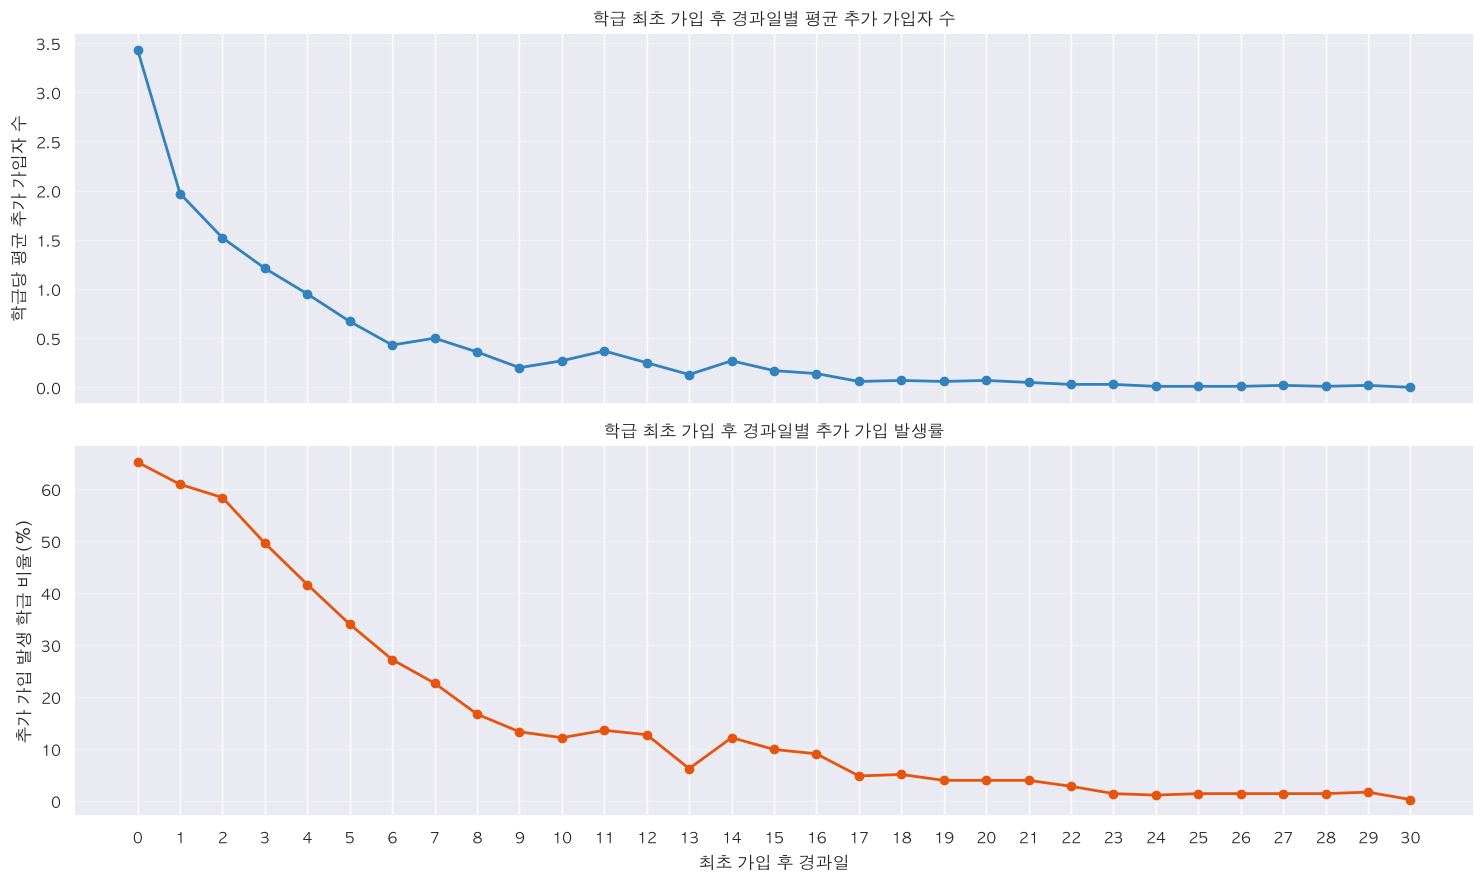

In [79]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# 학급당 평균 추가 가입자 수
axes[0].plot(
    daily_acquisition_summary['경과일'],
    daily_acquisition_summary['평균추가가입자수'],
    marker='o',
    linewidth=2,
    color='#3182bd',
)

axes[0].set_title('학급 최초 가입 후 경과일별 평균 추가 가입자 수')
axes[0].set_ylabel('학급당 평균 추가 가입자 수')
axes[0].grid(axis='y', alpha=0.3)

# 추가 가입 발생 학급 비율
axes[1].plot(
    daily_acquisition_summary['경과일'],
    daily_acquisition_summary['추가 가입 발생 학급 비율(%)'],
    marker='o',
    linewidth=2,
    color='#e6550d',
)

axes[1].set_title('학급 최초 가입 후 경과일별 추가 가입 발생률')
axes[1].set_xlabel('최초 가입 후 경과일')
axes[1].set_ylabel('추가 가입 발생 학급 비율(%)')
axes[1].set_xticks(range(0, followup_days + 1))
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()